# Q10.
```{admonition}
:class: note
We have seen that as the number of features used in a model increases, the training error will necessarily decrease, but the test error may not. We will now explore this in a simulated data set.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from itertools import combinations

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.dummy import DummyRegressor

## (a)
```{admonition}
:class: note
Generate a data set with $p = 20$ features, $n = 1\,000$ observations, and an associated quantitative response vector generated according to the model
$$
Y = X\beta+\varepsilon
$$
where $\beta$ has some elements that are exactly equal to zero.

In [2]:
rng = np.random.default_rng(1728)
n = 20
#cov_mat = rng.normal(size = (n,n))
#cov_mat = cov_mat@cov_mat.T
#X = rng.multivariate_normal(mean=np.zeros(n),size=1000,cov = cov_mat)
X = rng.normal(size=(1000,n))
B = np.hstack([rng.uniform(low=10,high=20,size=n//4),rng.uniform(low=0,high=1,size=n//4),[0]*(n-2*(n//4))])
#B[np.sort(rng.choice(n,size=7,replace=False))] = 0
Y = X@B+rng.normal(size=1000,scale=2)

## (b)
```{admonition}
:class: note
Split your data set into a training set containing 100 observations and a test set containing 900 observations.

In [3]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,random_state=1728,test_size=900)

## (c)
```{admonition}
:class: note
Perform best subset selection on the training set, and plot the training set MSE associated with the best model of each size.

In [220]:
def best_subset_selection(X:np.array, Y:np.array):
    X_train, X_test, Y_train, Y_test = train_test_split(X,Y,random_state=1728,test_size=0.9)
    n, p = X_train.shape
    best_k_features = {} #{k: (model, subset, train error, test error)}
    for k in range(p+1):
        if k==0:
            model = DummyRegressor()
            model.fit(X_train,Y_train)
            mse_train = mean_squared_error(Y_train,model.predict(X_train))
            mse_test = mean_squared_error(Y_test,model.predict(X_test))
            best_k_features[k] = (model,[],mse_train,mse_test)
        else:
            best_train_mse = np.inf
            for subset in combinations(range(p),k):
                features = list(subset)
                model = LinearRegression()
                model.fit(X_train[:,features],Y_train)
                mse_train = mean_squared_error(Y_train,model.predict(X_train[:,features]))
                if mse_train < best_train_mse:
                    best_train_mse = mse_train
                    best_model = model
                    best_subset = list(subset)
            best_k_features[k] = (best_model, best_subset, best_train_mse, mean_squared_error(Y_test,best_model.predict(X_test[:,best_subset])))
    return best_k_features

In [222]:
import time
start = time.perf_counter()
best_subset_selection(X,Y)
end = time.perf_counter()
print(f'Time: {end-start:.4f}')

Time: 25.2809


In [4]:
def mse_np(Y_real, Y_pred):
    return np.mean((Y_real-Y_pred)**2)

def best_subset_selection_np(X_train, X_test, Y_train, Y_test):
    n, p = X_train.shape
    best_k_features = {} #{k: (model, subset, train error, test error)}
    for k in range(p+1):
        if k==0:
            mse_train = mse_np(Y_train,np.mean(Y_train))
            mse_test = mse_np(Y_test,np.mean(Y_train))
            best_k_features[k] = (None,None,mse_train,mse_test)
        else:
            best_train_mse = np.inf
            for subset in combinations(range(p),k):
                X_train_sub = X_train[:,subset]
                beta, *_ = np.linalg.lstsq(X_train_sub,Y_train)
                Y_pred = X_train_sub @ beta
                mse_train = mse_np(Y_train,Y_pred)
                if mse_train < best_train_mse:
                    best_train_mse = mse_train
                    best_beta = beta
                    best_subset = subset
            best_k_features[k] = (best_beta, best_subset, best_train_mse, mse_np(Y_test,X_test[:,best_subset] @ best_beta))
    return best_k_features

In [18]:
from joblib import Parallel, delayed

def eval_subset(X_train, X_test, Y_train, Y_test,subset):
    X_train_sub = X_train[:,subset]
    beta, *_ = np.linalg.lstsq(X_train_sub,Y_train)
    Y_pred = X_train_sub @ beta
    mse_train = mse_np(Y_train,Y_pred)
    return (mse_train, beta, subset)
    
def best_subset_selection_np_parr(X_train, X_test, Y_train, Y_test,n_jobs):
    n, p = X_train.shape
    best_k_features = {} #{k: (model, subset, train error, test error)}
    for k in range(p+1):
        if k==0:
            mse_train = mse_np(Y_train,np.mean(Y_train))
            mse_test = mse_np(Y_test,np.mean(Y_train))
            best_k_features[k] = (None,None,mse_train,mse_test)
        else:
            subsets = list(combinations(range(p),k))
            results = Parallel(n_jobs=n_jobs)(
                delayed(eval_subset)(X_train, X_test, Y_train, Y_test,subset) for subset in subsets
            )
            
            best_train_mse, best_beta, best_subset = min(results, key=lambda x: x[0])
            mse_test = mse_np(Y_test, X_test[:,best_subset] @ best_beta)
            best_k_features[k] = (best_beta, best_subset, best_train_mse, mse_test)
            
    return best_k_features

In [19]:
import time
start = time.perf_counter()
best_models = best_subset_selection_np_parr(X_train, X_test, Y_train, Y_test,-1)
end = time.perf_counter()
print(f'Time: {end-start:.4f}')

Time: 23.6365


In [5]:
import time
start = time.perf_counter()
best_models = best_subset_selection_np(X_train, X_test, Y_train, Y_test)
end = time.perf_counter()
print(f'Time: {end-start:.4f}')

Time: 94.1570


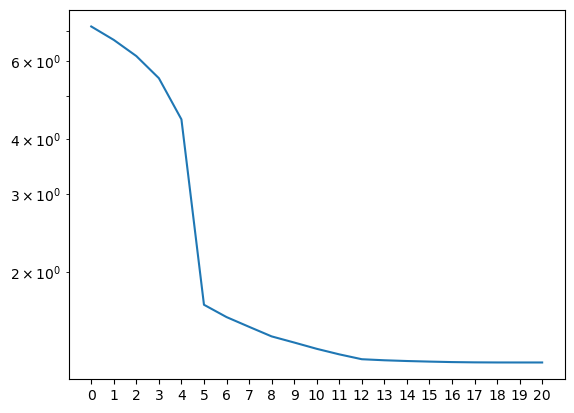

In [17]:
xs = np.arange(n+1)
train_preds = [best_models[i][2] for i in xs]
plt.plot(xs,np.log(train_preds))
plt.xticks(xs)
plt.yscale('log')
plt.show()

## (d)
```{admonition}
:class: note
Plot the test set MSE associated with the best model of each size.

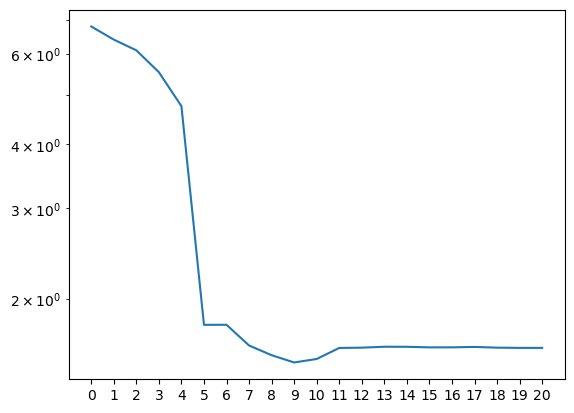

In [16]:
xs = np.arange(n+1)
test_preds = [best_models[i][3] for i in xs]
plt.plot(xs,np.log(test_preds))
plt.xticks(xs)
plt.yscale('log')
plt.show()

## (e)
```{admonition}
:class: note
For which model size does the test set MSE take on its minimum value?

In [8]:
min_test_model_id = np.argmin(test_preds)
print(f'Model size with lowest test error is {min_test_model_id}')

Model size with lowest test error is 9


## (f)
```{admonition}
:class: note
How does the model at which the test set MSE is minimized compare to the true model used to generate the data?

In [9]:
best_test_model = [(i,best_models[min_test_model_id][0][j]) for j,i in enumerate(best_models[min_test_model_id][1])]
true_values = [(i, b) for i, b in enumerate(B) if b != 0]
print('Minimal test model parameters:',[x[0] for x in best_test_model])
print('Actual non-zero parameters:',[x[0] for x in true_values])

Minimal test model parameters: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Actual non-zero parameters: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [10]:
[x[1] for x in best_test_model][:-1]+[0]+[[x[1] for x in best_test_model][-1]]

[np.float64(9.956915305887073),
 np.float64(13.318800993995255),
 np.float64(12.523862575342203),
 np.float64(18.32409775111422),
 np.float64(12.174660519075257),
 np.float64(0.4189232844440681),
 np.float64(0.6105429102820523),
 np.float64(0.662269311904136),
 0,
 np.float64(0.5752588407909456)]

In [11]:
[x[1] for x in true_values]

[np.float64(10.08168960728716),
 np.float64(13.107176830307894),
 np.float64(12.562246934086273),
 np.float64(18.201019372960797),
 np.float64(11.837620505479062),
 np.float64(0.42966133858081634),
 np.float64(0.3342602025392454),
 np.float64(0.5834155272803893),
 np.float64(0.9607202637816844),
 np.float64(0.11422674518562059)]

## (g)
```{admonition}
:class: note
Create a plot displaying
$
\sqrt{\sum_{j=1}^{p}(\beta_{j}-\hat{\beta}_{j}^{r})^{2}}
$, where $\hat{\beta}_{j}^{r}$ is the $j$th coefficient estimate for the best model containing $r$ coefficients. Comment on what you observe. How does this compare to the test MSE plot from (d)?

In [12]:
vals = []
for r in range(1,n+1):
    Br = np.where(np.arange(n)[:,None] == list(best_models[r][1]), best_models[r][0], 0).sum(axis=1)
    vals.append(np.linalg.norm(B-Br))

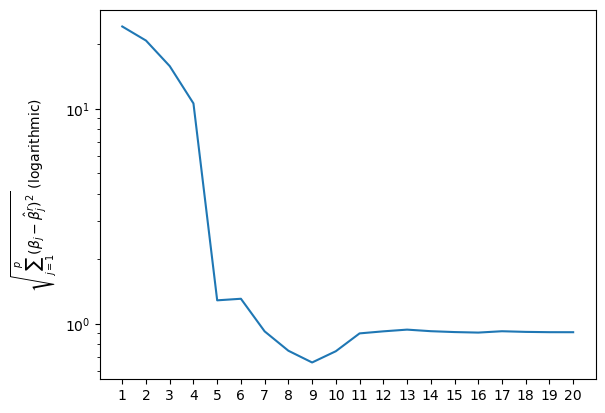

In [15]:
xs = np.arange(1,n+1)
plt.plot(xs,vals)
plt.xticks(xs)
plt.yscale('log')
plt.ylabel(r'$\sqrt{\sum_{j=1}^{p}(\beta_{j}-\hat{\beta}_{j}^{r})^{2}}$ (logarithmic)')
plt.show()